In [1]:
################################################################################
###                                                                          ###
### Created by Haotian XIAO, 2024-2027                                       ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
###                                                                          ###
### And Martin Genet, 2018-2025                                              ###
###                                                                          ###
### École Polytechnique, Palaiseau, France                                   ###
###                                                                          ###
################################################################################

#################################################################### imports ###




In [2]:
import sys
import dolfin
import math
import os
import json

import myPythonLibrary as mypy
import dolfin_mech as dmech


mat_params = {
    "alpha": 0.16,
    "gamma": 0.5,
    "c1": 0.2,
    "c2": 0.4,
    "kappa": 1,
    "eta": 1e-5,
}

dim = 2
bcs = "pbc"


def make_solid_loading(mode, n_steps, Umax=0.3, lambda_val=1.3):
    solid_loading = {}

    if mode == "stretch_x":
        solid_loading["U_bar_00_lst"] = [0.0, Umax]

    elif mode == "stretch_y":
        solid_loading["U_bar_11_lst"] = [0.0, Umax]

    elif mode == "pure_shear":
        solid_loading["U_bar_00_lst"] = [0.0, lambda_val - 1.0]
        solid_loading["U_bar_11_lst"] = [0.0, 1.0 / lambda_val - 1.0]

    elif mode == "gas_pressure":
        solid_loading["U_bar_00_lst"] = [0.0, 0.0]
        solid_loading["U_bar_11_lst"] = [0.0, 0.0]

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return solid_loading


def run_one_probe(
    r0,
    probe,
    mode,
    res_folder,
    prefix,
    pf=0.0,
    Umax=0.3,
    lambda_val=1.3,
):

    if probe == "gx":
        gx_fin_lst = [0.01, 0.01]
        gy_fin_lst = [0.0, 0.0]
    elif probe == "gy":
        gx_fin_lst = [0.0, 0.0]
        gy_fin_lst = [0.01, 0.01]
    else:
        raise ValueError("probe must be 'gx' or 'gy'")

    res_basename = f"{prefix}-r0={r0}-pf={pf}-{probe}"

    load_params = {
        "solid": {},
        "liquid": {},
        "air": {},
    }

    for i in range(dim):
        for j in range(dim):
            load_params["solid"]["sigma_bar_" + str(i) + str(j)] = 0.0

    n_steps = 2

    load_params["liquid"]["pl_bar_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["pl_bar_fin_lst"] = [0.0] * n_steps

    load_params["liquid"]["grad_p_bar_x_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["grad_p_bar_x_fin_lst"] = gx_fin_lst

    load_params["liquid"]["grad_p_bar_y_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["grad_p_bar_y_fin_lst"] = gy_fin_lst

    load_params["liquid"]["Theta_in_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["Theta_in_fin_lst"] = [0.0] * n_steps
    load_params["liquid"]["Theta_out_ini_lst"] = [0.0] * n_steps
    load_params["liquid"]["Theta_out_fin_lst"] = [0.0] * n_steps

    solid_loading = make_solid_loading(
        mode=mode,
        n_steps=n_steps,
        Umax=Umax,
        lambda_val=lambda_val,
    )

    for key, val in solid_loading.items():
        load_params["solid"][key] = val

    load_params["air"]["pf"] = pf

    dmech.run_HollowBox_MicroPoroflow(
        dim=dim,
        mesh_params={
            "dim": dim,
            "xmin": 0.0,
            "ymin": -math.sqrt(3) / 2,
            "xmax": 1.0,
            "ymax": math.sqrt(3) / 2,
            "r0": r0,
            "l": 0.03,
            "hole_shape": "hex",
            "add_center_hole": True,
            "mesh_filebasename": res_folder + f"/mesh-r0={r0}",
        },
        mat_params={
            "skel": {"parameters": mat_params, "scaling": "no"},
            "bulk": {"parameters": mat_params, "scaling": "no"},
            "pore": {"parameters": mat_params, "scaling": "no"},
        },
        flow_params={
            "k_l": dolfin.Constant(
                (
                    (1e-6, 0.0),
                    (0.0, 1e-6),
                )
            ),
            "use_kozeny_carman": False,
        },
        porosity_params={
            "type": "constant",
            "val": 0.3,
        },
        bcs=bcs,
        step_params={
            "n_steps": n_steps,
            "Deltat_lst": [1e-2, 1e-1],
            "dt_ini_lst": [1e-3, 1e-3],
            "dt_min_lst": [1e-4, 1e-4],
            "dt_max_lst": [5e-3, 5e-3],
        },
        load_params=load_params,
        res_basename=res_folder + "/" + res_basename,
        verbose=0,
    )

In [3]:
pf_list = [0.0, 0.2]
r0_list = [0.07, 0.2, 0.3, 0.41, 0.45]
for r0 in r0_list:
    for pf in pf_list:
        run_one_probe(
            r0=r0,
            probe="gx",
            mode="gas_pressure",
            res_folder="results_Figure7_pf",
            prefix="Fig7p",
            pf=pf,
            Umax=0.0,
            lambda_val=1.0,
        )

        run_one_probe(
            r0=r0,
            probe="gy",
            mode="gas_pressure",
            res_folder="results_Figure7_pf",
            prefix="Fig7p",
            pf=pf,
            Umax=0.0,
            lambda_val=1.0,
        )

Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of curve 12
Info    : Done meshing 1D (Wal

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of curve 12
Info    : Done meshing 1D (Wal

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of curve 12
Info    : Done meshing 1D (Wal

In [4]:

figure7_deformation_cases = [
    {
        "mode": "stretch_x",
        "res_folder": "results_Figure7_stretch_x",
        "prefix": "Fig7x",
        "pf": 0.0,
    },
    {
        "mode": "stretch_y",
        "res_folder": "results_Figure7_stretch_y",
        "prefix": "Fig7y",
        "pf": 0.0,
    },
    {
        "mode": "pure_shear",
        "res_folder": "results_Figure7_shear",
        "prefix": "Fig7s",
        "pf": 0.0,
    },
]

for case in figure7_deformation_cases:
    for r0 in r0_list:
        run_one_probe(
            r0=r0,
            probe="gx",
            mode=case["mode"],
            res_folder=case["res_folder"],
            prefix=case["prefix"],
            pf=case["pf"],
            Umax=0.3,
            lambda_val=1.3,
        )

        run_one_probe(
            r0=r0,
            probe="gy",
            mode=case["mode"],
            res_folder=case["res_folder"],
            prefix=case["prefix"],
            pf=case["pf"],
            Umax=0.3,
            lambda_val=1.3,
        )

Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of curve 12
Info    : Done meshing 1D (Wal

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of curve 12
Info    : Done meshing 1D (Wal

/opt/anaconda3/envs/dolfin-clean/lib/python3.10/site-packages/ufl/exproperators.py:336: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if arg in ("+", "-"):


Info    : Reconstructing periodicity for curve connection 6 - 12                                             
Info    : Reconstructing periodicity for curve connection 9 - 3
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 50%] Meshing curve 9 (Line) as a copy of curve 3
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 80%] Meshing curve 15 (Line)
Info    : [ 90%] Meshing curve 16 (Line)
Info    : [ 90%] Meshing curve 17 (Line)
Info    : [100%] Meshing curve 18 (Line)
Info    : [100%] Meshing curve 6 (Line) as a copy of curve 12
Info    : Done meshing 1D (Wal

PROJECT_DIR = /Users/xiao/PhD/Project_MicroPoroFlow
SRC_DIR = /Users/xiao/PhD/Project_MicroPoroFlow/src
stretch-x, r0=0.07, phi=0.014700, C_K=1.056145, A_K=2.128078, E_K=0.032688
stretch-x, r0=0.2, phi=0.120000, C_K=0.948060, A_K=1.732503, E_K=0.193263
stretch-x, r0=0.3, phi=0.270000, C_K=0.888271, A_K=1.468880, E_K=0.317306
stretch-x, r0=0.41, phi=0.504300, C_K=0.863812, A_K=1.285575, E_K=0.431504
stretch-x, r0=0.45, phi=0.607500, C_K=0.864803, A_K=1.236442, E_K=0.485824
stretch-y, r0=0.07, phi=0.014700, C_K=1.056397, A_K=2.128910, E_K=0.032515
stretch-y, r0=0.2, phi=0.120000, C_K=0.953202, A_K=1.760612, E_K=0.180281
stretch-y, r0=0.3, phi=0.270000, C_K=0.890125, A_K=1.484734, E_K=0.311984
stretch-y, r0=0.41, phi=0.504300, C_K=0.868885, A_K=1.217619, E_K=0.533867
stretch-y, r0=0.45, phi=0.607500, C_K=0.882260, A_K=1.141600, E_K=0.666178
pure shear, r0=0.07, phi=0.014700, C_K=1.121518, A_K=2.727245, E_K=0.033652
pure shear, r0=0.2, phi=0.120000, C_K=1.020837, A_K=2.085826, E_K=0.212061

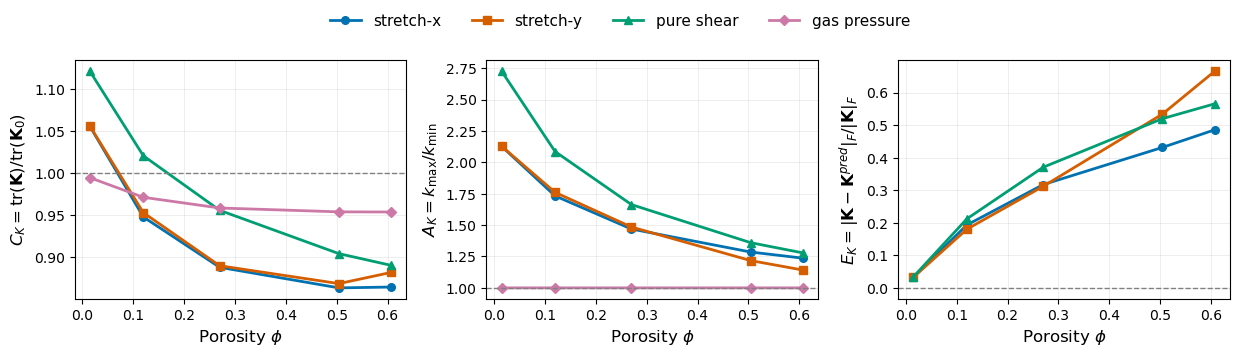

Saved: plots/Figure7_summary.png


In [5]:

from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parents[0]
SRC_DIR = PROJECT_DIR / "src"

sys.path.insert(0, str(SRC_DIR))
print("PROJECT_DIR =", PROJECT_DIR)
print("SRC_DIR =", SRC_DIR)

from Plot_Microporoflow import plot_fig7_summary

figure7_cases = [
    {
        "label": "stretch-x",
        "kind": "deformation",
        "res_folder": "results_Figure7_stretch_x",
        "prefix": "Fig7x",
        "pf": 0.0,
    },
    {
        "label": "stretch-y",
        "kind": "deformation",
        "res_folder": "results_Figure7_stretch_y",
        "prefix": "Fig7y",
        "pf": 0.0,
    },
    {
        "label": "pure shear",
        "kind": "deformation",
        "res_folder": "results_Figure7_shear",
        "prefix": "Fig7s",
        "pf": 0.0,
    },
    {
        "label": "gas pressure",
        "kind": "gas_pressure",
        "res_folder": "results_Figure7_pf",
        "prefix": "Fig7p",
        "pf_ref": 0.0,
        "pf_target": 0.2,
    },
]


rows = plot_fig7_summary(
    cases=figure7_cases,
    r0_list=r0_list,
    r0_to_phi=None,
    slice_start=5,
    final_index=-1,
    save_name="plots/Figure7_summary.png",
    show_plot=True,
)